# 03 — EDA and forecast-series selection

This notebook builds one auditable forecast-target catalog across all five normalized tables:

- `11l1`: official national targets;
- `11n1`: official broad-region targets, excluding its duplicate whole-country row;
- `12tu`: province-by-occupation targets;
- `12tw`: province-by-industry targets;
- `12r5`: detailed geographic targets and origin-safe context candidates.

ATP and KEHA definitions remain explicitly labelled and are never silently treated as the same statistic. Selection is deterministic. The default `configs/model_qwen3_4b_shared.yaml` selects `configs/eval_qwen3_4b_legacy.yaml`: only `12tu` and `12tw` become fine-tuning targets; the other tables remain benchmarks/context. The output is `data/processed/selected_series.csv`.


In [4]:
try:
    # mount Google Drive and set the working directory to the project path
    from google.colab import drive
    drive.mount("/content/drive")
    import os
    os.chdir("/content/drive/MyDrive/JobAI")  # the project path
    os.environ["JOBAI_REPO"] = "/content/drive/MyDrive/JobAI"
except ImportError:
    pass


In [5]:
import json, os
from pathlib import Path
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import yaml

def _find_repo():
    env = os.environ.get("JOBAI_REPO")
    if env:
        return Path(env).resolve()
    p = Path.cwd().resolve()
    for candidate in (p, *p.parents):
        if (candidate / "configs" / "eval.yaml").is_file():
            return candidate
    return p

REPO = _find_repo()
PRO = REPO / "data" / "processed"
REPORTS = REPO / "reports"
FIGURES = REPORTS / "figures"
REPORTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
import sys
sys.path.insert(0, str(REPO)) if str(REPO) not in sys.path else None
from jobai.configuration import load_profile
MODEL_CONFIG_PATH, MODEL_CFG, EVAL_CONFIG_PATH, EVAL = load_profile(REPO)
print("Active model/evaluation profiles:", MODEL_CONFIG_PATH.name, EVAL_CONFIG_PATH.name)
SEL = EVAL["panel_selection"]
SEED = int(EVAL["seed"])
np.random.seed(SEED)
print("repo:", REPO)
print("selection thresholds:", SEL)

Active model/evaluation profiles: model_qwen3_4b_shared.yaml eval_qwen3_4b_legacy.yaml
repo: /Users/Alan/Documents/Study/MLProject-JobAI
selection thresholds: {'minimum_non_null_quarters': 48, 'maximum_zero_fraction': 0.5, 'minimum_variance': 1e-12, 'target_tables': ['12tu', '12tw'], 'target_contentscodes': {'11l1': ['atp_lkm', 'atp_eihoit', 'atp_osa', 'atp_maar', 'atp_vaik'], '11n1': ['atp_lkm'], '12tu': ['AVPAIKATYHT'], '12tw': ['AVPAIKATLOPUSSA'], '12r5': ['AVPAIKATLOPUSSA', 'UUDETAVP']}}


## Preflight and normalized-data inventory

**What this code does:** confirms that all five normalized CSV files and the notebook 02 assertion report exist and passed validation. It then displays their sizes and quarterly coverage before EDA begins.

In [6]:
from jobai.forecasting import verify_normalization
required_tables = ["11l1", "11n1", "12tu", "12tw", "12r5"]
normalization_checks = verify_normalization(REPO, required_tables, check_sources=True)
inventory = pd.DataFrame([
    {"table_id": tid, **normalization_checks[tid]} for tid in required_tables
])[["table_id", "n_rows", "n_series", "n_quarters", "time_first", "time_last"]]
display(inventory)

,table_id,n_rows,n_series,n_quarters,time_first,time_last
0,11l1,270,5,54,2013Q1,2026Q2
1,11n1,270,5,54,2013Q1,2026Q2
2,12tu,445284,8246,54,2013Q1,2026Q2
3,12tw,150290,2147,70,2009Q1,2026Q2
4,12r5,58940,842,70,2009Q1,2026Q2


## Dataset A — official benchmark targets

`11l1` supplies the authoritative whole-country Job Vacancy Survey targets. `11n1` supplies four broad regions; its `SSS` whole-country row is excluded because it duplicates the `11l1/atp_lkm` national series.

**Selection-helper code:** defines a stable series ID and records quality, target scope, source role, context eligibility, and duplicate provenance for every candidate.


In [7]:
MIN_NON_NULL = int(SEL["minimum_non_null_quarters"])
MAX_ZERO = float(SEL["maximum_zero_fraction"])
MIN_VARIANCE = float(SEL["minimum_variance"])

def series_identifier(table_id, dimensions):
    return table_id + "::" + "|".join(f"{key}={dimensions[key]}" for key in dimensions)

def summarize_group(table_id, family, role, dimensions, frame, forecast_scope,
                    is_forecast_target, is_auxiliary_feature=False,
                    duplicate_group="", authoritative_source="",
                    force_selected=None, force_reason=""):
    values = pd.to_numeric(frame["value"], errors="coerce")
    valid = values.dropna()
    n_periods = int(frame["timeperiod_q"].nunique())
    n_non_null = int(valid.size)
    zero_fraction = float((valid == 0).mean()) if n_non_null else 1.0
    variance = float(valid.var(ddof=0)) if n_non_null else 0.0
    reasons = []
    if n_non_null < MIN_NON_NULL:
        reasons.append("insufficient_non_null_quarters")
    if zero_fraction > MAX_ZERO:
        reasons.append("mostly_zero")
    if not np.isfinite(variance) or variance <= MIN_VARIANCE:
        reasons.append("no_variation")
    selected = not reasons if force_selected is None else bool(force_selected)
    reason = force_reason if force_selected is not None else ("accepted" if selected else ";".join(reasons))
    return {
        "table_id": table_id, "series_family": family, "role": role,
        "series_id": series_identifier(table_id, dimensions),
        "dimensions_json": json.dumps(dimensions, ensure_ascii=False, sort_keys=True),
        "forecast_scope": forecast_scope,
        "measure_code": str(dimensions.get("contentscode", "")),
        "is_forecast_target": bool(is_forecast_target),
        "is_auxiliary_feature": bool(is_auxiliary_feature),
        "duplicate_group": duplicate_group,
        "authoritative_source": authoritative_source or table_id,
        "n_periods": n_periods, "n_non_null": n_non_null,
        "coverage_ratio": n_non_null / n_periods if n_periods else 0.0,
        "zero_fraction": zero_fraction, "variance": variance,
        "time_first": frame["timeperiod_q"].min(), "time_last": frame["timeperiod_q"].max(),
        "selected": bool(selected), "selection_reason": reason,
    }


### Select the official ATP targets

**What this code does:** evaluates all configured national measures in `11l1` and the broad-region vacancy series in `11n1`. It marks direct forecast targets explicitly and records the excluded `11n1/SSS` duplicate rather than silently deleting it.


In [8]:
catalog_rows = []
target_codes = SEL["target_contentscodes"]

national = pd.read_csv(PRO / "11l1__normalized.csv", low_memory=False)
national = national[national["contentscode"].isin(target_codes["11l1"])].copy()
for content, group in national.groupby("contentscode", sort=True, dropna=False):
    catalog_rows.append(summarize_group(
        "11l1", "ATP_official", "benchmark_target", {"contentscode": str(content)}, group,
        forecast_scope="national", is_forecast_target=True, is_auxiliary_feature=True,
        authoritative_source="11l1",
    ))

regional = pd.read_csv(PRO / "11n1__normalized.csv", low_memory=False)
regional = regional[regional["contentscode"].isin(target_codes["11n1"])].copy()
for (region, content), group in regional.groupby(["alue_16_20180101", "contentscode"], sort=True, dropna=False):
    is_total = str(region) == "SSS"
    catalog_rows.append(summarize_group(
        "11n1", "ATP_official", "excluded_duplicate" if is_total else "benchmark_target",
        {"alue_16_20180101": str(region), "contentscode": str(content)}, group,
        forecast_scope="national" if is_total else "broad_region",
        is_forecast_target=not is_total, is_auxiliary_feature=not is_total,
        duplicate_group="ATP_national_job_vacancies" if is_total else "",
        authoritative_source="11l1" if is_total else "11n1",
        force_selected=False if is_total else None,
        force_reason="duplicate_of_11l1_national" if is_total else "",
    ))

benchmark = pd.DataFrame(catalog_rows)
assert ((benchmark["table_id"] == "11l1") & benchmark["selected"] & benchmark["is_forecast_target"]).any()
assert int(((benchmark["table_id"] == "11n1") & benchmark["selected"] & benchmark["is_forecast_target"]).sum()) == 4
display(benchmark[["series_id", "role", "forecast_scope", "measure_code", "selected", "selection_reason"]])


,series_id,role,forecast_scope,measure_code,selected,selection_reason
0,11l1::contentscode=atp_eihoit,benchmark_target,national,atp_eihoit,True,accepted
1,11l1::contentscode=atp_lkm,benchmark_target,national,atp_lkm,True,accepted
2,11l1::contentscode=atp_maar,benchmark_target,national,atp_maar,True,accepted
3,11l1::contentscode=atp_osa,benchmark_target,national,atp_osa,True,accepted
4,11l1::contentscode=atp_vaik,benchmark_target,national,atp_vaik,True,accepted
5,11n1::alue_16_20180101=SA1|contentscode=atp_lkm,benchmark_target,broad_region,atp_lkm,True,accepted
6,11n1::alue_16_20180101=SA2|contentscode=atp_lkm,benchmark_target,broad_region,atp_lkm,True,accepted
7,11n1::alue_16_20180101=SA3|contentscode=atp_lkm,benchmark_target,broad_region,atp_lkm,True,accepted
8,11n1::alue_16_20180101=SA4|contentscode=atp_lkm,benchmark_target,broad_region,atp_lkm,True,accepted
9,11n1::alue_16_20180101=SSS|contentscode=atp_lkm,excluded_duplicate,national,atp_lkm,False,duplicate_of_11l1_national


### Plot official ATP targets over time

**What this code does:** draws each national measure separately and adds the four broad-region vacancy totals. This keeps different measures from being connected into one misleading line.


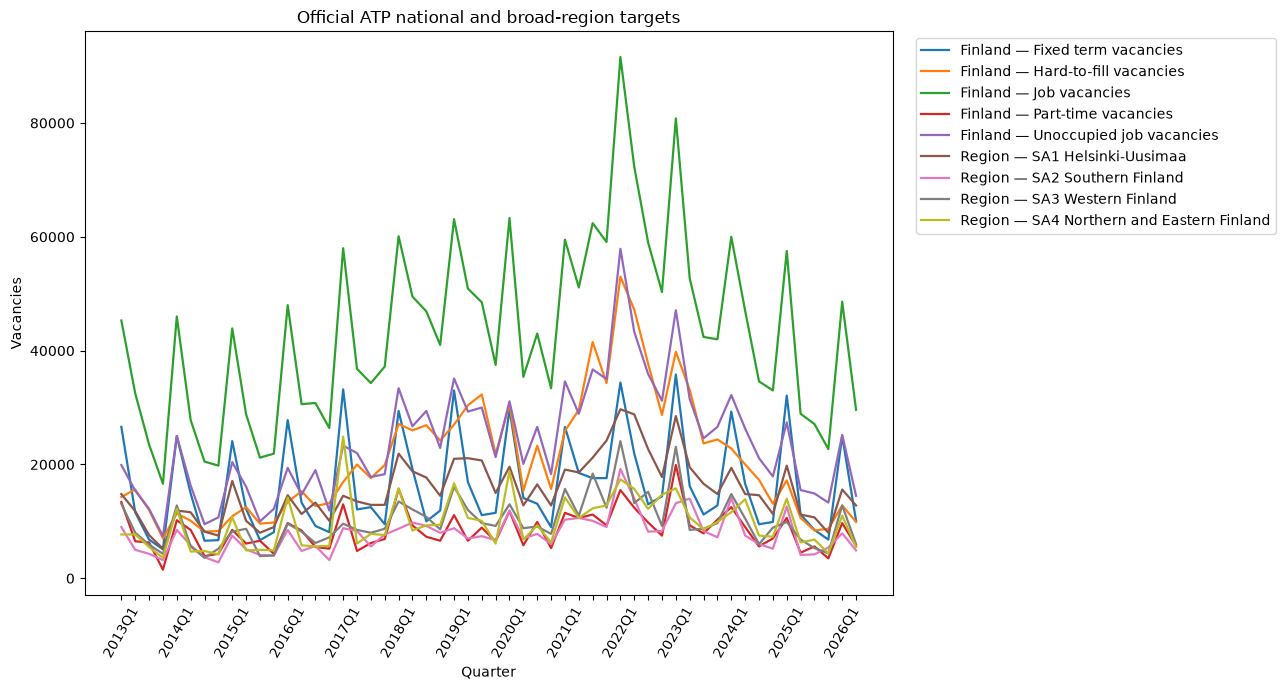

In [9]:
plot_frames = []
for measure, group in national.groupby("contentscode_text", sort=True):
    plot_frames.append(group.assign(series_label=f"Finland — {measure}"))
for region, group in regional[regional["alue_16_20180101"] != "SSS"].groupby("alue_16_20180101_text"):
    plot_frames.append(group.assign(series_label=f"Region — {region}"))
plot_data = pd.concat(plot_frames, ignore_index=True)
fig, ax = plt.subplots(figsize=(13, 7))
for label, group in plot_data.groupby("series_label"):
    ax.plot(group["timeperiod_q"], group["value"], label=label, linewidth=1.6)
ax.set(title="Official ATP national and broad-region targets", xlabel="Quarter", ylabel="Vacancies")
ax.tick_params(axis="x", rotation=60)
for index, label in enumerate(ax.get_xticklabels()):
    label.set_visible(index % 4 == 0)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES / "03_dataset_a_targets.png", dpi=150, bbox_inches="tight")
plt.show()


## Dataset B — KEHA panel candidates

`12tu` contributes province-by-occupation targets, `12tw` contributes province-by-industry targets, and `12r5` contributes national and detailed geographic candidates. The active legacy profile keeps `12r5` for context/inventory, not training. `12r5` is also eligible as origin-safe context.

The exact `12r5` province/end-of-month rows already represented by `12tw` total-industry series are retained in the catalog but marked as excluded duplicates.


In [10]:
tu = pd.read_csv(PRO / "12tu__normalized.csv", low_memory=False)
tu = tu[(tu["contentscode"] == "AVPAIKATYHT") & (tu["Työmarkkina-asema"] == "SSS")].copy()
for keys, group in tu.groupby(["Alue", "Ammattiryhmä", "Työmarkkina-asema", "contentscode"], sort=True, dropna=False):
    dims = dict(zip(["Alue", "Ammattiryhmä", "Työmarkkina-asema", "contentscode"], map(str, keys)))
    catalog_rows.append(summarize_group("12tu", "KEHA_occupation", "panel_target", dims, group,
        forecast_scope="province_occupation", is_forecast_target=True, authoritative_source="12tu"))
del tu

tw = pd.read_csv(PRO / "12tw__normalized.csv", low_memory=False)
tw = tw[tw["contentscode"] == "AVPAIKATLOPUSSA"].copy()
tw_dims = ["Alue", "Toimiala", "Työnantajan sektori", "Työpaikan työn kesto", "contentscode"]
for keys, group in tw.groupby(tw_dims, sort=True, dropna=False):
    dims = dict(zip(tw_dims, map(str, keys)))
    catalog_rows.append(summarize_group(
        "12tw", "KEHA_industry", "panel_target", dims, group,
        forecast_scope="province_industry", is_forecast_target=True,
        authoritative_source="12tw",
    ))
tw_total_mask = (
    tw["Toimiala"].astype(str).eq("SSS")
    & tw["Työnantajan sektori"].astype(str).eq("SSS")
    & tw["Työpaikan työn kesto"].astype(str).eq("SSS")
)
tw_total_regions = set(tw.loc[tw_total_mask, "Alue"].astype(str))
del tw

def r5_scope(area_code):
    code = str(area_code)
    if code == "SSS":
        return "national_keha"
    if code.startswith("KU"):
        return "municipality"
    if code.startswith("ELY"):
        return "ely_region"
    if code.startswith("SK"):
        return "subregion"
    if code.startswith("MK"):
        return "province"
    return "other_geography"

r5 = pd.read_csv(PRO / "12r5__normalized.csv", low_memory=False)
r5 = r5[r5["contentscode"].isin(target_codes["12r5"])].copy()
for keys, group in r5.groupby(["Alue", "contentscode"], sort=True, dropna=False):
    area, content = map(str, keys)
    dims = {"Alue": area, "contentscode": content}
    duplicate_tw_total = content == "AVPAIKATLOPUSSA" and area in tw_total_regions
    catalog_rows.append(summarize_group(
        "12r5", "KEHA_geography", "excluded_duplicate" if duplicate_tw_total else "geographic_target",
        dims, group, forecast_scope=r5_scope(area),
        is_forecast_target=not duplicate_tw_total,
        is_auxiliary_feature=not duplicate_tw_total,
        duplicate_group=f"KEHA_province_end_month::{area}" if duplicate_tw_total else "",
        authoritative_source="12tw" if duplicate_tw_total else "12r5",
        force_selected=False if duplicate_tw_total else None,
        force_reason="duplicate_of_12tw_province_total" if duplicate_tw_total else "",
    ))

catalog = pd.DataFrame(catalog_rows).sort_values(["role", "table_id", "series_id"]).reset_index(drop=True)
active_tables = set(SEL["target_tables"])
catalog["is_forecast_target"] &= catalog["table_id"].isin(active_tables)
# Benchmarks/context remain in the inventory, but do not become legacy training targets.
catalog_path = PRO / "selected_series.csv"
catalog.to_csv(catalog_path, index=False)
selected_targets = catalog[catalog["selected"] & catalog["is_forecast_target"]]
minimum_panel_series = int(EVAL["finetuning_gate"]["minimum_selected_panel_series"])
series_gate_passed = len(selected_targets) >= minimum_panel_series
print("selected-series catalog:", catalog_path)
print("selected targets by table:")
display(selected_targets.groupby(["table_id", "forecast_scope"]).size().rename("n_series").reset_index())
print("selected direct targets:", len(selected_targets))
print("fine-tuning series gate:", "PASS" if series_gate_passed else f"FAIL ({len(selected_targets)} < {minimum_panel_series})")


selected-series catalog: /Users/Alan/Documents/Study/MLProject-JobAI/data/processed/selected_series.csv
selected targets by table:


,table_id,forecast_scope,n_series
0,12tu,province_occupation,842
1,12tw,province_industry,837


selected direct targets: 1679
fine-tuning series gate: PASS


### Summarize and visualize the selection decision

**What this code does:** reports accepted and rejected candidates across every target family. The charts show completeness and zero frequency for direct forecast candidates, while duplicate rows remain visible in the saved audit table.


,table_id,role,forecast_scope,selected,selection_reason,n_series
0,11l1,benchmark_target,national,True,accepted,5
1,11n1,benchmark_target,broad_region,True,accepted,4
2,11n1,excluded_duplicate,national,False,duplicate_of_11l1_national,1
3,12r5,excluded_duplicate,province,False,duplicate_of_12tw_province_total,19
4,12r5,geographic_target,ely_region,False,mostly_zero,4
5,12r5,geographic_target,ely_region,True,accepted,32
6,12r5,geographic_target,municipality,False,insufficient_non_null_quarters,115
7,12r5,geographic_target,municipality,False,insufficient_non_null_quarters;mostly_zero,22
8,12r5,geographic_target,municipality,False,mostly_zero,4
9,12r5,geographic_target,municipality,True,accepted,479


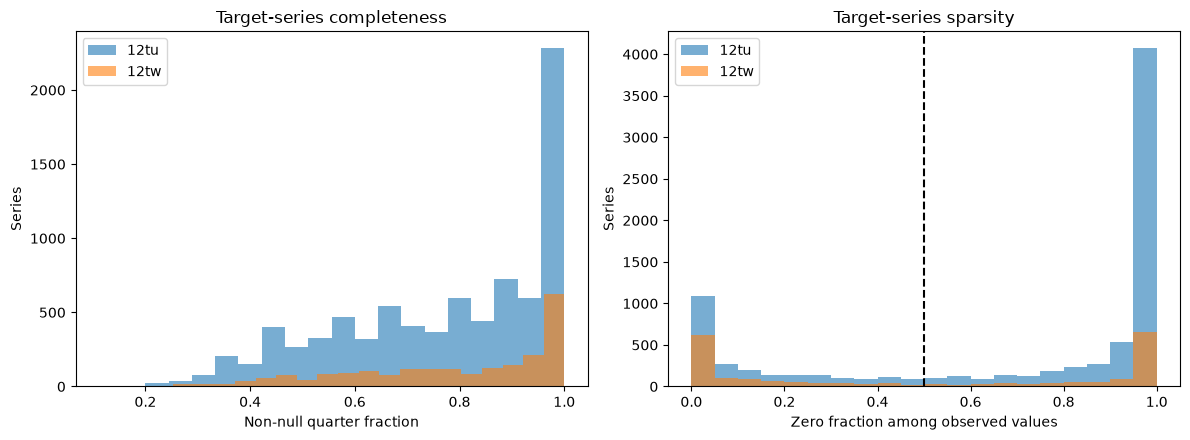

In [11]:
summary = (catalog.groupby(["table_id", "role", "forecast_scope", "selected", "selection_reason"], dropna=False)
           .size().rename("n_series").reset_index())
summary_path = REPORTS / "series_selection_summary.csv"
summary.to_csv(summary_path, index=False)
display(summary)

target_candidates = catalog[catalog["is_forecast_target"]]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for table_id, group in target_candidates.groupby("table_id"):
    axes[0].hist(group["coverage_ratio"], bins=20, alpha=0.6, label=table_id)
    axes[1].hist(group["zero_fraction"], bins=20, alpha=0.6, label=table_id)
axes[0].set(title="Target-series completeness", xlabel="Non-null quarter fraction", ylabel="Series")
axes[1].axvline(MAX_ZERO, color="black", linestyle="--")
axes[1].set(title="Target-series sparsity", xlabel="Zero fraction among observed values", ylabel="Series")
for ax in axes:
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "03_panel_selection_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()


## Selection contract

Notebooks 04 and 05 use quality-passing rows marked `is_forecast_target` whose table is allowed by the active profile. The shared Qwen3-4B default uses `12tu` and `12tw`; all five tables remain in the catalog. ATP and `12r5` are not evidence that the saved final adapter was trained on those targets.

Duplicate concepts remain visible for auditing. Statistical definitions, series families, and geographic scopes stay separate.
